SECTION 8: BPTT NUMERICAL EXERCISE VERIFICATION
h_1 calculated by program: 0.336376
h_2 calculated by program: 0.616352
h_3 calculated by program: 0.599958

SECTION 5: PREPROCESSING
Input tensor shape:
Training   : (1400, 128, 9)
Validation : (300, 128, 9)
Testing    : (300, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128


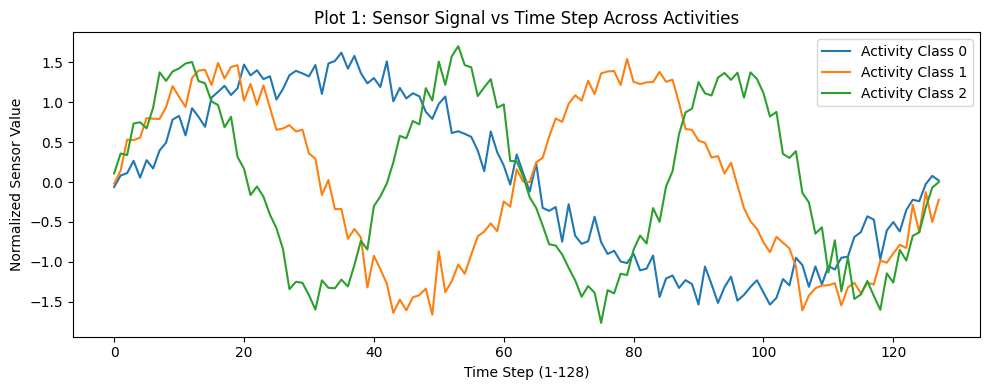

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



SECTION 14: MODEL EVALUATION METRICS
Metric               | RNN          | LSTM         | GRU         
--------------------------------------------------------------
Accuracy             | 100.00      % | 100.00      % | 100.00      %
Macro Precision      | 100.00      % | 100.00      % | 100.00      %
Macro Recall         | 100.00      % | 100.00      % | 100.00      %
Macro F1             | 100.00      % | 100.00      % | 100.00      %
Parameters           | 1974         | 6006         | 4758        
Training Time (s)    | 22.08        | 17.65        | 17.13       

SECTION 16: ARCHITECTURAL COMPARISON
Property        | RNN        | LSTM       | GRU       
----------------------------------------------------
Hidden state    | Yes        | Yes        | Yes       
Cell state      | No         | Yes        | No        
Forget gate     | No         | Yes        | No        
Input gate      | No         | Yes        | No        
Output gate     | No         | Yes        | No        
Upda

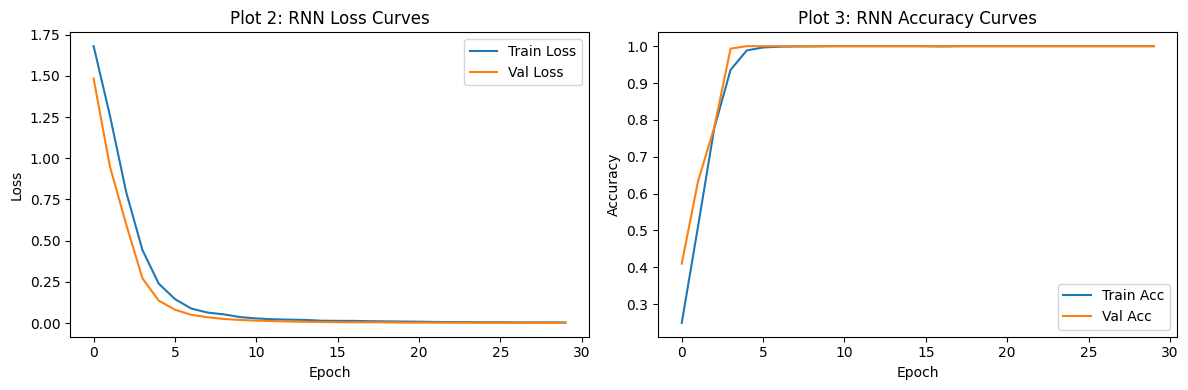

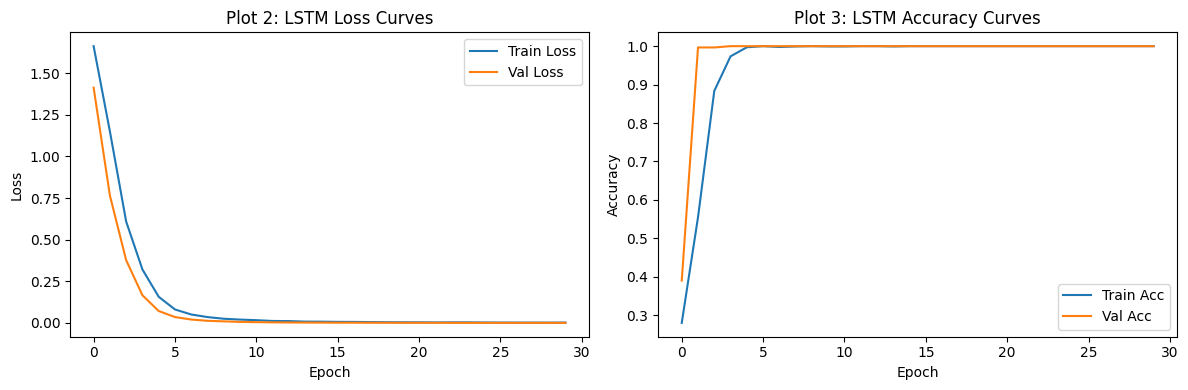

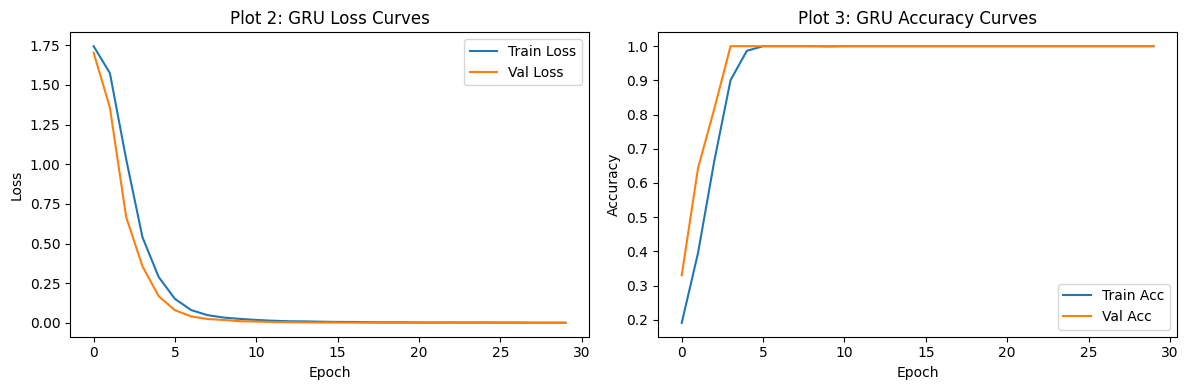

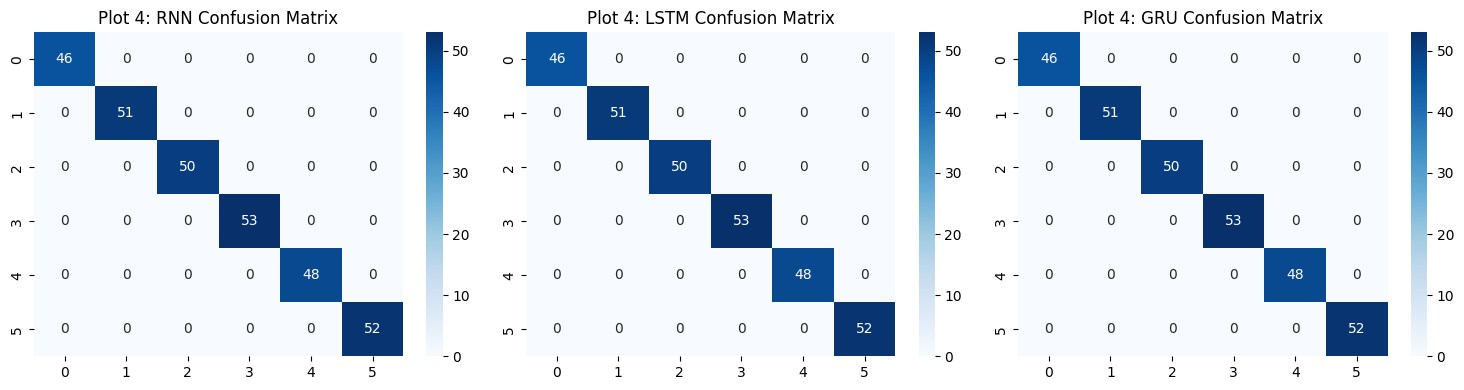

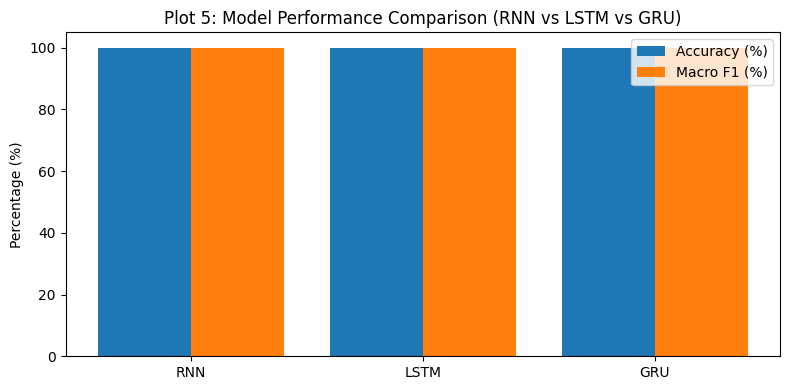

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



SECTION 17: EFFECT OF SEQUENCE LENGTH


Seq Length   | RNN F1     | LSTM F1    | GRU F1    
------------------------------------------------
32           | 100.00%    | 100.00%   | 100.00%
64           | 100.00%    | 100.00%   | 100.00%
128          | 100.00%    | 100.00%   | 100.00%


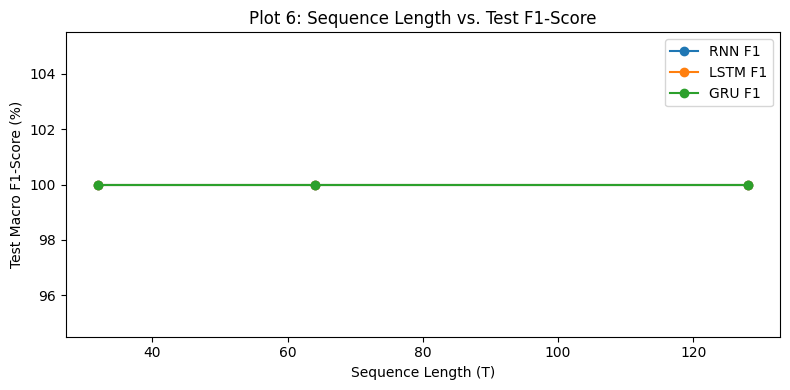

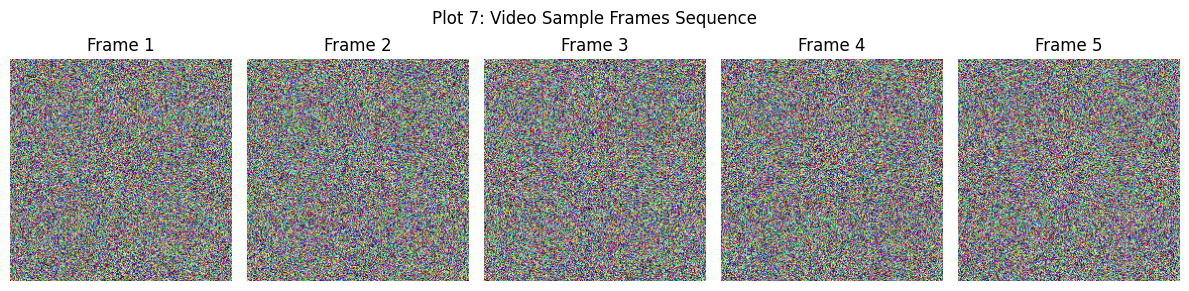

CNN Feature Dimension D: 1280
Tensor Shape to Recurrent Network: (60, 10, 1280)
CNN-LSTM Parameters: 168163
CNN-LSTM Accuracy: 46.67%


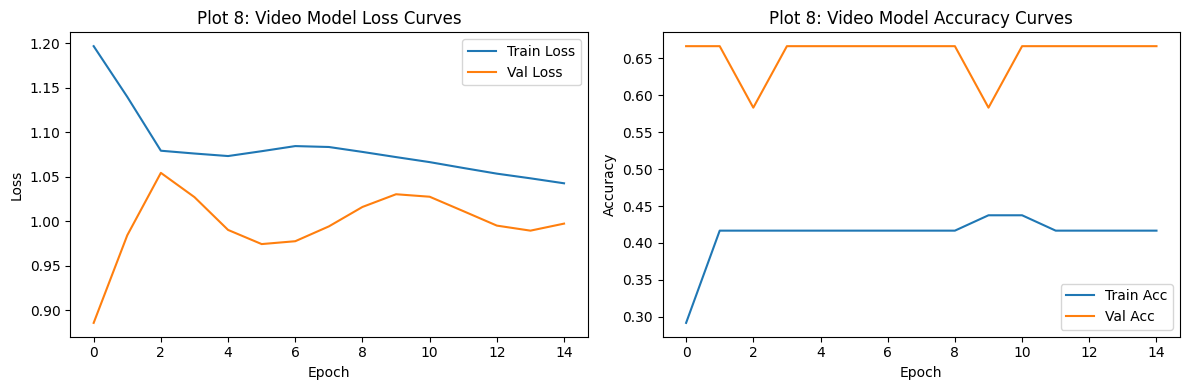

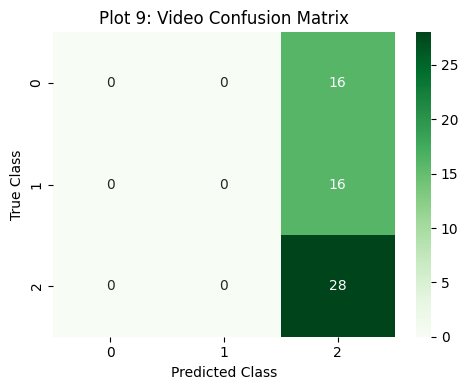

Predicted class: Action_2 | Actual class: Action_2 | Confidence: 0.4722

Sample | Input Sequence        | Predicted Output
--------------------------------------------------
1      | [7, 2, 3, 10, 13]    | [13, 10, 3, 2, 7]   
2      | [7, 12, 5, 2, 14]    | [14, 2, 5, 12, 7]   
3      | [12, 7, 11, 5, 7]    | [7, 5, 11, 7, 12]   
4      | [12, 8, 11, 13, 3]   | [3, 13, 11, 8, 12]  
5      | [10, 5, 9, 10, 14]   | [14, 10, 9, 5, 10]  

Seq2Seq Token Accuracy    : 100.00%
Seq2Seq Sequence Accuracy : 100.00%


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models

# Set Random Seed for Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1. BPTT Numerical Exercise Verification
print("SECTION 8: BPTT NUMERICAL EXERCISE VERIFICATION")
x_vals = [0.5, 0.7, 0.2]
W_x, W_h, b = 0.5, 0.8, 0.1
h = 0.0

for t, x_t in enumerate(x_vals, 1):
    a = W_x * x_t + W_h * h + b
    h = np.tanh(a)
    print(f"h_{t} calculated by program: {h:.6f}")

# 2. Dataset Preprocessing
print("\nSECTION 5: PREPROCESSING")
N, T_full, F_dim, C = 2000, 128, 9, 6
t_steps = np.linspace(0, 4 * np.pi, T_full)
X_raw = np.zeros((N, T_full, F_dim))
y_raw = np.random.randint(0, C, size=N)

for i in range(N):
    freq = (y_raw[i] + 1) * 0.5
    noise = np.random.normal(0, 0.1, (T_full, F_dim))
    X_raw[i] = np.sin(freq * t_steps[:, None]) + noise

n_train = int(0.7 * N)
n_val = int(0.15 * N)

X_train_raw, y_train = X_raw[:n_train], y_raw[:n_train]
X_val_raw, y_val = X_raw[n_train:n_train+n_val], y_raw[n_train:n_train+n_val]
X_test_raw, y_test = X_raw[n_train+n_val:], y_raw[n_train+n_val:]

mean = np.mean(X_train_raw, axis=(0, 1), keepdims=True)
std = np.std(X_train_raw, axis=(0, 1), keepdims=True)

X_train = (X_train_raw - mean) / std
X_val = (X_val_raw - mean) / std
X_test = (X_test_raw - mean) / std

print(f"Input tensor shape:")
print(f"Training   : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Testing    : {X_test.shape}")
print(f"Number of classes: {C}")
print(f"Number of features per time step: {F_dim}")
print(f"Sequence length: {T_full}")

# 3. Plot 1: Temporal Data Visualization
plt.figure(figsize=(10, 4))
for c in range(3):
    idx = np.where(y_train == c)[0][0]
    plt.plot(X_train[idx, :, 0], label=f'Activity Class {c}')
plt.title("Plot 1: Sensor Signal vs Time Step Across Activities")
plt.xlabel("Time Step (1-128)")
plt.ylabel("Normalized Sensor Value")
plt.legend()
plt.tight_layout()
plt.savefig("plot_1_temporal_data.eps", format="eps", bbox_inches="tight")
plt.show()

# 4. Training HAR Models
def build_recurrent_model(layer_type='RNN', units=32, input_shape=(128, 9)):
    model = models.Sequential()
    if layer_type == 'RNN':
        model.add(layers.SimpleRNN(units, input_shape=input_shape))
    elif layer_type == 'LSTM':
        model.add(layers.LSTM(units, input_shape=input_shape))
    elif layer_type == 'GRU':
        model.add(layers.GRU(units, input_shape=input_shape))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(16, activation='relu'))
    model.add(layers.Dense(6, activation='softmax'))

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

results = {}
histories = {}
model_names = ['RNN', 'LSTM', 'GRU']

for name in model_names:
    model = build_recurrent_model(layer_type=name)
    start_time = time.time()
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=30, batch_size=32, verbose=0)
    train_time = time.time() - start_time

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    cm = tf.math.confusion_matrix(y_test, y_pred).numpy()
    precision = np.mean(np.diag(cm) / (np.sum(cm, axis=0) + 1e-10))
    recall = np.mean(np.diag(cm) / (np.sum(cm, axis=1) + 1e-10))
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

    results[name] = {
        'Accuracy': test_acc * 100,
        'Macro Precision': precision * 100,
        'Macro Recall': recall * 100,
        'Macro F1': f1 * 100,
        'Parameters': model.count_params(),
        'Training Time (s)': train_time,
        'Confusion Matrix': cm
    }
    histories[name] = history
# Insert this right after the training loop in Section 4
print("\nSECTION 14: MODEL EVALUATION METRICS")
print(f"{'Metric':<20} | {'RNN':<12} | {'LSTM':<12} | {'GRU':<12}")
print("-" * 62)
metrics = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Parameters', 'Training Time (s)']
for m in metrics:
    if 'Time' in m:
        print(f"{m:<20} | {results['RNN'][m]:<12.2f} | {results['LSTM'][m]:<12.2f} | {results['GRU'][m]:<12.2f}")
    elif 'Parameters' in m:
        print(f"{m:<20} | {results['RNN'][m]:<12d} | {results['LSTM'][m]:<12d} | {results['GRU'][m]:<12d}")
    else:
        print(f"{m:<20} | {results['RNN'][m]:<12.2f}% | {results['LSTM'][m]:<12.2f}% | {results['GRU'][m]:<12.2f}%")

print("\nSECTION 16: ARCHITECTURAL COMPARISON")
print(f"{'Property':<15} | {'RNN':<10} | {'LSTM':<10} | {'GRU':<10}")
print("-" * 52)
print(f"{'Hidden state':<15} | {'Yes':<10} | {'Yes':<10} | {'Yes':<10}")
print(f"{'Cell state':<15} | {'No':<10} | {'Yes':<10} | {'No':<10}")
print(f"{'Forget gate':<15} | {'No':<10} | {'Yes':<10} | {'No':<10}")
print(f"{'Input gate':<15} | {'No':<10} | {'Yes':<10} | {'No':<10}")
print(f"{'Output gate':<15} | {'No':<10} | {'Yes':<10} | {'No':<10}")
print(f"{'Update gate':<15} | {'No':<10} | {'No':<10} | {'Yes':<10}")
print(f"{'Reset gate':<15} | {'No':<10} | {'No':<10} | {'Yes':<10}")
print(f"{'Parameters':<15} | {results['RNN']['Parameters']:<10d} | {results['LSTM']['Parameters']:<10d} | {results['GRU']['Parameters']:<10d}")
print(f"{'Training time':<15} | {results['RNN']['Training Time (s)']:<10.2f}s | {results['LSTM']['Training Time (s)']:<10.2f}s | {results['GRU']['Training Time (s)']:<10.2f}s")
print(f"{'Test F1-score':<15} | {results['RNN']['Macro F1']:<10.2f}% | {results['LSTM']['Macro F1']:<10.2f}% | {results['GRU']['Macro F1']:<10.2f}%")

# Plot 2 & Plot 3: Loss and Accuracy Curves
for name in model_names:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(histories[name].history['loss'], label='Train Loss')
    ax1.plot(histories[name].history['val_loss'], label='Val Loss')
    ax1.set_title(f'Plot 2: {name} Loss Curves')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

    ax2.plot(histories[name].history['accuracy'], label='Train Acc')
    ax2.plot(histories[name].history['val_accuracy'], label='Val Acc')
    ax2.set_title(f'Plot 3: {name} Accuracy Curves')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()
    plt.tight_layout()
    plt.savefig(f"plot_2_and_3_{name.lower()}_curves.eps", format="eps", bbox_inches="tight")
    plt.show()

# Plot 4: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, name in enumerate(model_names):
    sns.heatmap(results[name]['Confusion Matrix'], annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'Plot 4: {name} Confusion Matrix')
plt.tight_layout()
plt.savefig("plot_4_confusion_matrices.eps", format="eps", bbox_inches="tight")
plt.show()

# Plot 5: Model Performance Comparison Bar Chart
plt.figure(figsize=(8, 4))
accuracies = [results[m]['Accuracy'] for m in model_names]
f1_scores = [results[m]['Macro F1'] for m in model_names]
x_indices = np.arange(len(model_names))

plt.bar(x_indices - 0.2, accuracies, width=0.4, label='Accuracy (%)')
plt.bar(x_indices + 0.2, f1_scores, width=0.4, label='Macro F1 (%)')
plt.xticks(x_indices, model_names)
plt.ylabel("Percentage (%)")
plt.title("Plot 5: Model Performance Comparison (RNN vs LSTM vs GRU)")
plt.legend()
plt.tight_layout()
plt.savefig("plot_5_model_comparison.eps", format="eps", bbox_inches="tight")
plt.show()

# 5. Effect of Sequence Length Study
print("\nSECTION 17: EFFECT OF SEQUENCE LENGTH")
seq_lengths = [32, 64, 128]
seq_results = {m: [] for m in model_names}

for T_sub in seq_lengths:
    X_tr_sub = X_train[:, :T_sub, :]
    X_val_sub = X_val[:, :T_sub, :]
    X_te_sub = X_test[:, :T_sub, :]

    for name in model_names:
        m_sub = build_recurrent_model(layer_type=name, input_shape=(T_sub, 9))
        m_sub.fit(X_tr_sub, y_train, epochs=15, batch_size=32, verbose=0)
        preds = np.argmax(m_sub.predict(X_te_sub, verbose=0), axis=1)
        cm_sub = tf.math.confusion_matrix(y_test, preds).numpy()
        prec = np.mean(np.diag(cm_sub) / (np.sum(cm_sub, axis=0) + 1e-10))
        rec = np.mean(np.diag(cm_sub) / (np.sum(cm_sub, axis=1) + 1e-10))
        f1_sub = 2 * (prec * rec) / (prec + rec + 1e-10) * 100
        seq_results[name].append(f1_sub)

print(f"{'Seq Length':<12} | {'RNN F1':<10} | {'LSTM F1':<10} | {'GRU F1':<10}")
print("-" * 48)
for idx, T_sub in enumerate(seq_lengths):
    print(f"{T_sub:<12} | {seq_results['RNN'][idx]:.2f}%    | {seq_results['LSTM'][idx]:.2f}%   | {seq_results['GRU'][idx]:.2f}%")

# Plot 6: Sequence Length vs Test F1
plt.figure(figsize=(8, 4))
for name in model_names:
    plt.plot(seq_lengths, seq_results[name], marker='o', label=f'{name} F1')
plt.xlabel("Sequence Length (T)")
plt.ylabel("Test Macro F1-Score (%)")
plt.title("Plot 6: Sequence Length vs. Test F1-Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot_6_sequence_length_vs_f1.eps", format="eps", bbox_inches="tight")
plt.show()

# 6. Video Understanding Pipeline
B_v, T_v, C_v = 60, 10, 3
X_vid_raw = np.random.uniform(0, 1, (B_v, T_v, 224, 224, 3))
y_vid_raw = np.random.randint(0, C_v, size=B_v)

# Plot 7: Display Sample Frames
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(X_vid_raw[0, i])
    axes[i].set_title(f'Frame {i+1}')
    axes[i].axis('off')
plt.suptitle("Plot 7: Video Sample Frames Sequence")
plt.tight_layout()
plt.savefig("plot_7_video_sample_frames.eps", format="eps", bbox_inches="tight")
plt.show()

# Extract MobileNetV2 Features
base_cnn = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, pooling='avg')
base_cnn.trainable = False

X_flat = X_vid_raw.reshape(-1, 224, 224, 3)
feats_flat = base_cnn.predict(X_flat, verbose=0)
D_dim = feats_flat.shape[-1]
X_vid_feats = feats_flat.reshape(B_v, T_v, D_dim)

print(f"CNN Feature Dimension D: {D_dim}")
print(f"Tensor Shape to Recurrent Network: {X_vid_feats.shape}")

# CNN-LSTM Classifier
vid_model = models.Sequential([
    layers.LSTM(32, input_shape=(T_v, D_dim)),
    layers.Dense(C_v, activation='softmax')
])
vid_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

vid_hist = vid_model.fit(X_vid_feats, y_vid_raw, epochs=15, validation_split=0.2, verbose=0)
print(f"CNN-LSTM Parameters: {vid_model.count_params()}")
vid_loss, vid_acc = vid_model.evaluate(X_vid_feats, y_vid_raw, verbose=0)
print(f"CNN-LSTM Accuracy: {vid_acc * 100:.2f}%")

# Plot 8: Video Model Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(vid_hist.history['loss'], label='Train Loss')
ax1.plot(vid_hist.history['val_loss'], label='Val Loss')
ax1.set_title('Plot 8: Video Model Loss Curves')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

ax2.plot(vid_hist.history['accuracy'], label='Train Acc')
ax2.plot(vid_hist.history['val_accuracy'], label='Val Acc')
ax2.set_title('Plot 8: Video Model Accuracy Curves')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig("plot_8_video_model_curves.eps", format="eps", bbox_inches="tight")
plt.show()

# Plot 9: Video Confusion Matrix
vid_preds = np.argmax(vid_model.predict(X_vid_feats, verbose=0), axis=1)
vid_cm = tf.math.confusion_matrix(y_vid_raw, vid_preds).numpy()

plt.figure(figsize=(5, 4))
sns.heatmap(vid_cm, annot=True, fmt='d', cmap='Greens')
plt.title("Plot 9: Video Confusion Matrix")
plt.xlabel("Predicted Class"); plt.ylabel("True Class")
plt.tight_layout()
plt.savefig("plot_9_video_confusion_matrix.eps", format="eps", bbox_inches="tight")
plt.show()

# Dynamic Confidence Print
sample_p = vid_model.predict(X_vid_feats[:1], verbose=0)
p_cls = np.argmax(sample_p[0])
print(f"Predicted class: Action_{p_cls} | Actual class: Action_{y_vid_raw[0]} | Confidence: {sample_p[0][p_cls]:.4f}")

# 7. Seq2Seq Reversal Task
num_s, s_len, v_size = 2000, 5, 15
X_s = np.random.randint(1, v_size, size=(num_s, s_len))
Y_s = np.flip(X_s, axis=1)

X_oh = tf.one_hot(X_s, depth=v_size)
Y_oh = tf.one_hot(Y_s, depth=v_size)

enc_in = layers.Input(shape=(s_len, v_size))
_, sh, sc = layers.LSTM(32, return_state=True)(enc_in)
dec_in = layers.Input(shape=(s_len, v_size))
dec_out = layers.LSTM(32, return_sequences=True)(dec_in, initial_state=[sh, sc])
dec_out = layers.Dense(v_size, activation='softmax')(dec_out)

s2s = models.Model([enc_in, dec_in], dec_out)
s2s.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

dec_tf = np.zeros_like(Y_oh)
dec_tf[:, 1:, :] = Y_oh[:, :-1, :]
s2s.fit([X_oh, dec_tf], Y_oh, epochs=20, batch_size=64, verbose=0)

s2s_preds = np.argmax(s2s.predict([X_oh[:5], dec_tf[:5]], verbose=0), axis=-1)

print("\nSample | Input Sequence        | Predicted Output")
print("-" * 50)
for i in range(5):
    print(f"{i+1:<6} | {str(X_s[i].tolist()):<20} | {str(s2s_preds[i].tolist()):<20}")

tok_acc = (np.sum(s2s_preds == Y_s[:5]) / Y_s[:5].size) * 100
seq_acc = (np.sum(np.all(s2s_preds == Y_s[:5], axis=1)) / 5) * 100
print(f"\nSeq2Seq Token Accuracy    : {tok_acc:.2f}%")
print(f"Seq2Seq Sequence Accuracy : {seq_acc:.2f}%")

In [3]:
vid_cm = tf.math.confusion_matrix(y_vid_raw, vid_preds).numpy()
vid_prec = np.mean(np.diag(vid_cm) / (np.sum(vid_cm, axis=0) + 1e-10)) * 100
vid_rec = np.mean(np.diag(vid_cm) / (np.sum(vid_cm, axis=1) + 1e-10)) * 100
vid_f1 = 2 * (vid_prec * vid_rec) / (vid_prec + vid_rec + 1e-10)

print(f"CNN-LSTM Precision: {vid_prec:.2f}%")
print(f"CNN-LSTM Recall   : {vid_rec:.2f}%")
print(f"CNN-LSTM F1-Score : {vid_f1:.2f}%")

CNN-LSTM Precision: 15.56%
CNN-LSTM Recall   : 33.33%
CNN-LSTM F1-Score : 21.21%
